In [346]:
import sys
import os
import mne
from pathlib import Path
import matplotlib.pyplot as plt
from src.eeg_processor import EEGProcessor

In [ ]:
# Get the first subject for processing
ROOT_DIR = os.getcwd()
data_folder = os.path.join(ROOT_DIR, "..", "data")
file_path = "derivatives/sub-001/eeg/sub-001_task-eyesclosed_eeg.set"

processor = EEGProcessor(data_folder, file_path)

In [345]:
# Load data
raw_data = processor.load_data()

# Epoch data
epochs_data = processor.epoch_data()

# Compute PSD
psds, freqs, ch_names = processor.compute_psd()

# Compute alpha-band power
band_psd = processor.compute_band_psd(
    band="alpha"
)

# Map the alpha power to 5x5 grid
mapped_data = processor.map_channel_locations()

# Interpolate each grid to 32x32
interpolated_data = processor.interpolate()


Not setting metadata
599 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 599 events and 500 original time points ...
0 bad epochs dropped
Effective window size : 1.000 (s)


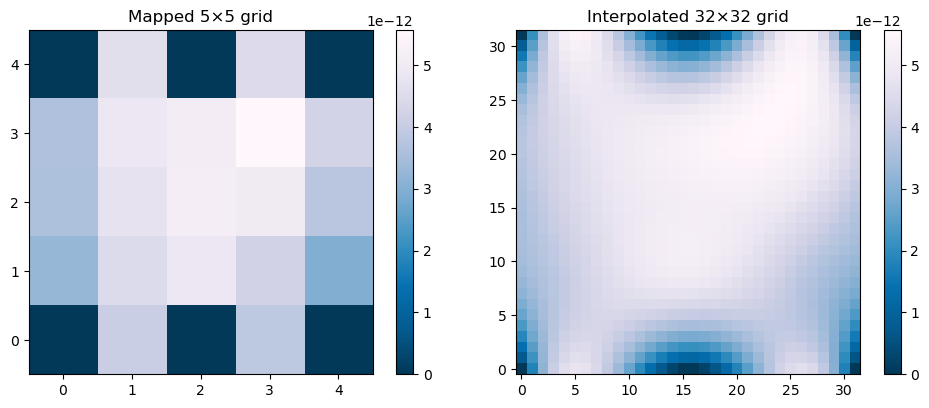

In [347]:
epoch_ind = 5

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(mapped_data[epoch_ind], cmap='PuBu_r', origin="lower")
plt.title("Mapped 5×5 grid")
plt.colorbar()

plt.subplot(1, 2, 2)
plt.imshow(interpolated_data[epoch_ind], cmap="PuBu_r", origin="lower")
plt.title("Interpolated 32×32 grid") 
plt.colorbar()

plt.tight_layout()
plt.show()

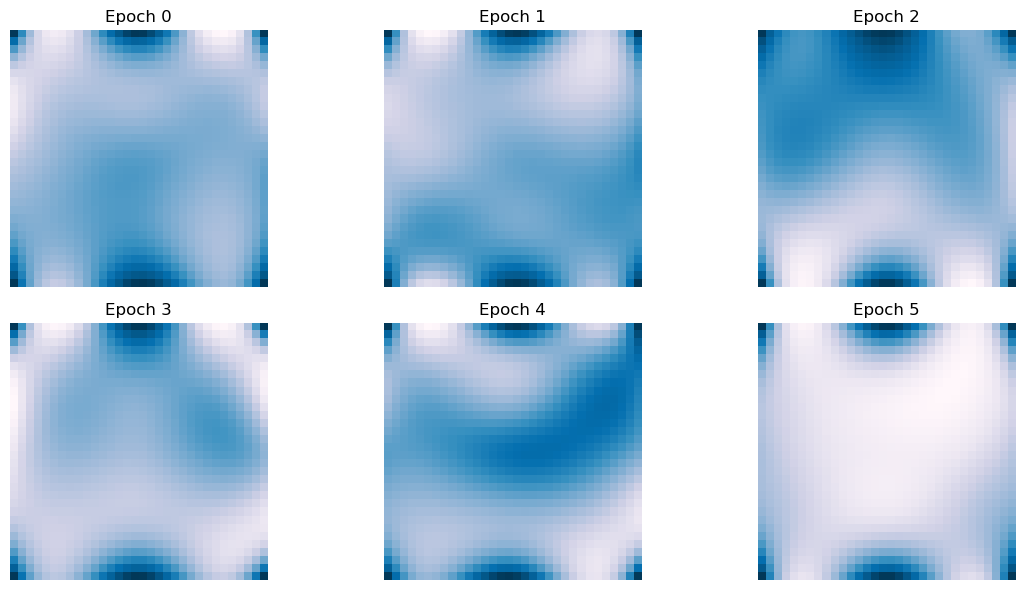

In [355]:
n = 6
plt.figure(figsize=(12, 6))
for i in range(n):
    plt.subplot(2, 3, i+1)
    plt.imshow(interpolated_data[i], cmap="PuBu_r", origin="lower")
    plt.title(f"Epoch {i}")
    plt.axis("off")
plt.tight_layout()
plt.show()

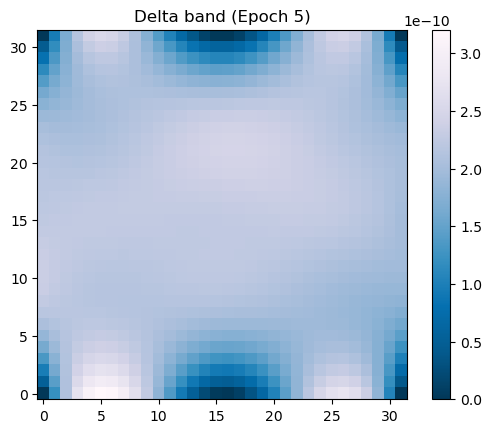

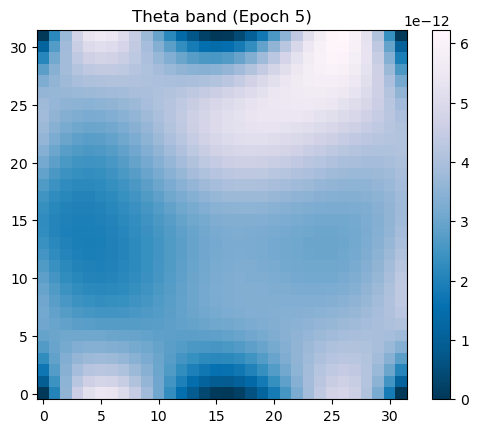

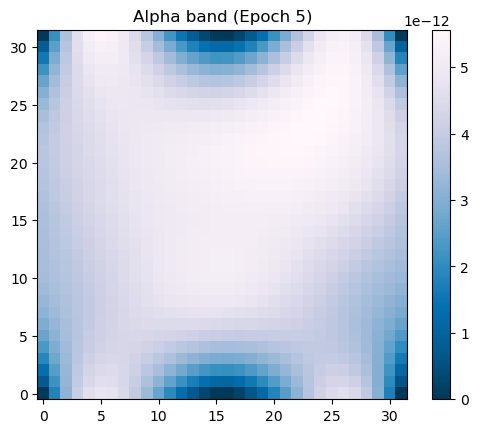

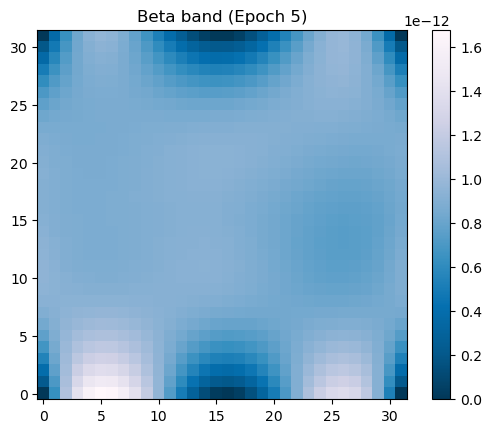

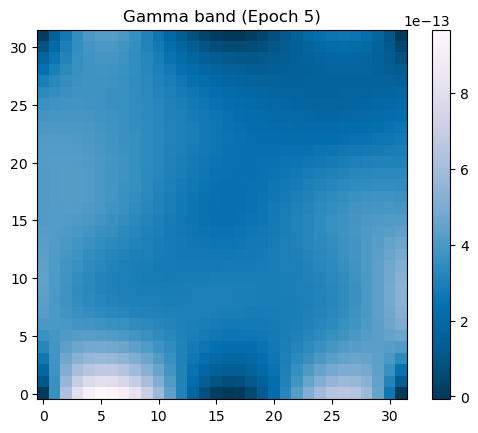

In [358]:
epoch_ind = 5
    
for band in ["delta", "theta", "alpha", "beta", "gamma"]:
    band_psd = processor.compute_band_psd(band=band)
    mapped = processor.map_channel_locations()
    interpolated = processor.interpolate()
    plt.imshow(interpolated[epoch_ind], cmap="PuBu_r", origin="lower")
    plt.title(f"{band.capitalize()} band (Epoch {epoch_ind})")
    plt.colorbar()
    plt.show()